✅ Libraries loaded successfully!
✅ Loaded 145 rows of data

📊 Data prepared for forecasting:
   Date Range: 2015-05-13 00:00:00 to 2018-12-25 00:00:00
   Total Days: 69

🔄 Training the Prophet model...


11:22:33 - cmdstanpy - INFO - Chain [1] start processing
11:22:34 - cmdstanpy - INFO - Chain [1] done processing


✅ Model training complete!
✅ Future dates created: 249 days total
✅ Forecast generated!

📊 Forecast Preview (Next 10 days):
            ds        yhat  yhat_lower  yhat_upper
239 2019-06-14 -349.500020 -905.117172  245.358119
240 2019-06-15 -319.700915 -824.677571  248.595288
241 2019-06-16 -280.044802 -859.457561  292.319369
242 2019-06-17 -230.610431 -801.866852  297.108108
243 2019-06-18 -171.697426 -707.553811  385.509796
244 2019-06-19 -103.830731 -660.206212  452.246537
245 2019-06-20  -27.759947 -580.703039  525.116747
246 2019-06-21   55.546584 -502.929389  613.594232
247 2019-06-22  144.912988 -355.514214  678.954433
248 2019-06-23  238.972263 -306.025798  807.221572


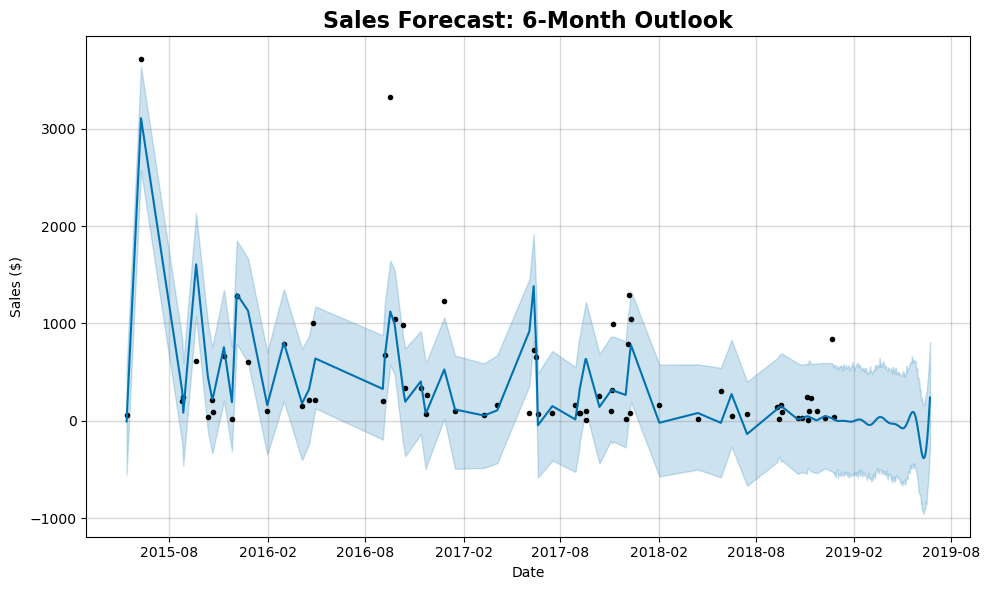

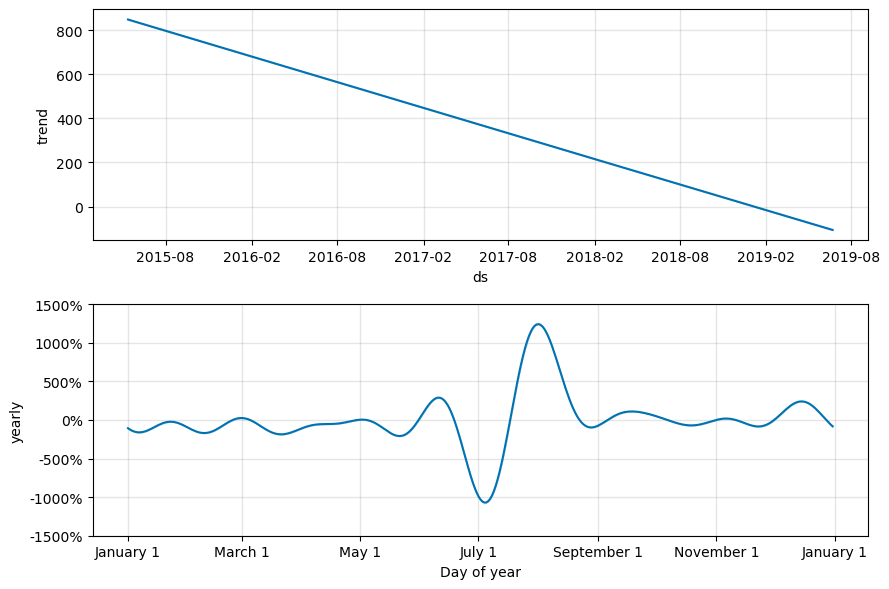


📊 FORECAST SUMMARY

📈 Total Forecasted Sales (6 months): $-5,582.76
📊 Average Daily Sales: $-31.02
📅 Peak Day: 2019-06-23 ($238.97)

✅ Forecast saved to: data/sales_forecast.csv

✅ Forecasting Complete!


In [3]:
# =====================================================
# Sales Forecasting - Facebook Prophet
# Project: Sales Performance & Forecasting Dashboard
# Author: Jose Cordoba
# Date: July 2026
# =====================================================

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

# 2. Load the Cleaned Data
df = pd.read_csv('../data/cleaned_sales_data.csv')
print(f"✅ Loaded {len(df)} rows of data")

# 3. Prepare Data for Prophet
# Prophet requires columns named 'ds' (date) and 'y' (value)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df_prophet = df.groupby('OrderDate')['Sales'].sum().reset_index()
df_prophet.columns = ['ds', 'y']  # Rename columns to match Prophet's requirements

print(f"\n📊 Data prepared for forecasting:")
print(f"   Date Range: {df_prophet['ds'].min()} to {df_prophet['ds'].max()}")
print(f"   Total Days: {len(df_prophet)}")

# 4. Display the prepared data
df_prophet.head()

# 5. Create and Train the Prophet Model
print("\n🔄 Training the Prophet model...")

# Configure the model
model = Prophet(
    yearly_seasonality=True,      # Capture yearly patterns (e.g., holiday seasons)
    weekly_seasonality=False,     # Disable weekly patterns (we are forecasting monthly sales)
    daily_seasonality=False,      # Disable daily patterns
    seasonality_mode='multiplicative'  # Better for growing trends
)

# Fit the model to the data
model.fit(df_prophet)
print("✅ Model training complete!")

# 6. Create Future Dates (Forecast Horizon)
# Forecast 180 days (approx 6 months) into the future
future = model.make_future_dataframe(periods=180)
print(f"✅ Future dates created: {len(future)} days total")

# 7. Make Predictions
forecast = model.predict(future)
print("✅ Forecast generated!")

# 8. View the Forecast Results
print("\n📊 Forecast Preview (Next 10 days):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

# 9. Plot the Forecast
fig = model.plot(forecast)
plt.title('Sales Forecast: 6-Month Outlook', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Plot the Forecast Components (Trend, Seasonality)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

# 11. Extract Forecast Summary
last_date = df_prophet['ds'].max()
forecast_future = forecast[forecast['ds'] > last_date]

total_forecast = forecast_future['yhat'].sum()
avg_daily_forecast = forecast_future['yhat'].mean()
peak_day = forecast_future.loc[forecast_future['yhat'].idxmax()]

print("\n" + "="*50)
print("📊 FORECAST SUMMARY")
print("="*50)
print(f"\n📈 Total Forecasted Sales (6 months): ${total_forecast:,.2f}")
print(f"📊 Average Daily Sales: ${avg_daily_forecast:,.2f}")
print(f"📅 Peak Day: {peak_day['ds'].strftime('%Y-%m-%d')} (${peak_day['yhat']:,.2f})")

# 12. Save Forecast to CSV
forecast.to_csv('../data/sales_forecast.csv', index=False)
print(f"\n✅ Forecast saved to: data/sales_forecast.csv")

print("\n" + "="*50)
print("✅ Forecasting Complete!")
print("="*50)